In [1]:
# ============================================================
#  run_census_income_ppci_mean_twofold_cf_sweepN.py
#
#  Small change: only run (sex=1, age=70), but sweep N_unlab_total:
#    N_unlab_total in {1000, 2000, ..., 11000}
#  Save ONE row per N to CSV (checkpointing each N).
# ============================================================

import os
import sys
import csv
import numpy as np
import cupy as cp

from ppi_py.datasets import load_dataset
from ppi_py import ppi_mean_ci, ppi_mean_pointestimate

# 兼容：脚本里用 __file__，notebook 里用 os.getcwd()
try:
    current_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    current_dir = os.getcwd()

parent_dir = os.path.abspath(os.path.join(current_dir, ".."))
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

from conditional_mean_functions import (
    preprocess_X,
    make_age_groups,
    select_logell_by_pilot_logo_cv,
    nw_point_mean_ci_matern52,
    build_twofold_weights,
    ppci_conditional_mean_cf,
    ppci_conditional_mean_label_only_cf,
)

np.set_printoptions(precision=4, suppress=True)


# ============================================================
# Helper: ddof=1 std from sums
# ============================================================
def std_ddof1_from_sums(sum_x: float, sum_x2: float, n: int) -> float:
    if n <= 1:
        return 0.0
    var = (sum_x2 - (sum_x * sum_x) / n) / (n - 1)
    return float(np.sqrt(max(var, 0.0)))


# ============================================================
# Helper: checkpoint writer (rewrite whole CSV each row)
# ============================================================
def write_results_to_csv(results_list, csv_path):
    if len(results_list) == 0:
        raise ValueError("results_list is empty; nothing to write.")
    fieldnames = list(results_list[0].keys())
    with open(csv_path, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        for row in results_list:
            writer.writerow(row)
    print(f"\n[Saved Checkpoint] {csv_path}")


# ============================================================
# Core: run one x0 with NEW logic (aggregate over R*B)
# (copied from your original; unchanged)
# ============================================================
def run_one_x0_income_twofold_cf(
    Y: np.ndarray,
    Yhat: np.ndarray,
    X_raw: np.ndarray,
    X_scaled: np.ndarray,
    X_mean: np.ndarray,
    X_std: np.ndarray,
    X_full_gpu,
    Y_full_gpu,
    X_pilot_gpu,
    Y_pilot_gpu,
    pilot_groups: np.ndarray,
    pilot_idx: np.ndarray,
    seed_split: int,
    R: int,
    B: int,
    n_label: int,
    N_unlab_total: int,
    lam_grid: np.ndarray,
    LOGELL_grid_size: int,
    c_min: float,
    c_max: float,
    z_alpha: float,
    alpha: float,
    x0_raw: np.ndarray,
    theta0_mode: str = "smooth",
):
    N_total = int(len(Y))

    x0_raw = np.asarray(x0_raw, dtype=float).ravel()
    x0_scaled = (x0_raw - X_mean) / X_std
    x0_gpu = cp.asarray(x0_scaled)

    mask_x0 = np.all(X_raw == x0_raw.reshape(1, -1), axis=1)
    n_x0 = int(mask_x0.sum())
    print(f"[x0 = {x0_raw}] exact duplicate observations (excluded from pool): {n_x0}")

    theta0_obs = float(np.mean(Y[mask_x0])) if np.any(mask_x0) else np.nan

    dists_full = np.linalg.norm(X_scaled - x0_scaled.reshape(1, -1), axis=1)
    ell_oracle = float(np.median(dists_full))
    theta0_s, _, _ = nw_point_mean_ci_matern52(
        X_l=X_full_gpu,
        Y_l=Y_full_gpu,
        x0=x0_gpu,
        ell=ell_oracle,
        z_alpha=z_alpha,
    )
    theta0_smooth = float(theta0_s)

    if theta0_mode == "obs":
        if np.isnan(theta0_obs):
            raise ValueError("theta0_mode='obs' but x0 has no exact obs.")
        theta0 = theta0_obs
        theta0_source = "obs"
    elif theta0_mode == "smooth":
        theta0 = theta0_smooth
        theta0_source = "smooth"
    elif theta0_mode == "mix":
        if not np.isnan(theta0_obs):
            theta0 = theta0_obs
            theta0_source = "obs"
        else:
            theta0 = theta0_smooth
            theta0_source = "smooth"
    else:
        raise ValueError("theta0_mode must be 'obs'/'smooth'/'mix'.")

    pilot_mask = np.zeros(N_total, dtype=bool)
    pilot_mask[pilot_idx] = True

    base_pool = np.where((~pilot_mask) & (~mask_x0))[0]
    M = int(len(base_pool))

    if M < (N_unlab_total + n_label):
        raise ValueError(
            f"[x0={x0_raw}] base_pool size={M} too small for N_unlab_total={N_unlab_total} "
            f"+ n_label={n_label}. Reduce N_unlab_total or n_label."
        )

    d_pilot = cp.linalg.norm(X_pilot_gpu - x0_gpu[None, :], axis=1)
    ell0_hat = float(cp.asnumpy(cp.median(d_pilot)))
    ell0_hat = max(1e-8, ell0_hat)

    ell_low = max(1e-8, c_min * ell0_hat)
    ell_high = c_max * ell0_hat

    LOGELL_grid_local = np.linspace(np.log(ell_low), np.log(ell_high), int(LOGELL_grid_size))

    ell_star, _ = select_logell_by_pilot_logo_cv(
        LOGELL_grid=LOGELL_grid_local,
        X_pilot=X_pilot_gpu,
        Y_pilot=Y_pilot_gpu,
        group_labels=pilot_groups,
    )
    ell_star = float(ell_star)

    total_reps = int(R * B)

    # PPCI
    sum_th_ppci = 0.0
    sum_sqerr_ppci = 0.0
    sum_cov_ppci = 0.0
    sum_width_ppci = 0.0
    sum_s2_Ymf = 0.0
    sum_s2_Ymf2 = 0.0
    sum_s2_f = 0.0
    sum_s2_f2 = 0.0

    # LO
    sum_th_lo = 0.0
    sum_sqerr_lo = 0.0
    sum_cov_lo = 0.0
    sum_width_lo = 0.0
    sum_s2_Y = 0.0
    sum_s2_Y2 = 0.0

    # PPI
    sum_th_ppi = 0.0
    sum_sqerr_ppi = 0.0
    sum_cov_ppi = 0.0
    sum_width_ppi = 0.0

    # diagnostics over r
    sum_lam1 = 0.0
    sum_lam2 = 0.0
    sum_den_u = 0.0

    x0_tag = int(10_000 * int(x0_raw[0]) + 100 * int(x0_raw[1]))

    for r in range(1, R + 1):
        rng_xu = np.random.default_rng(seed_split + 2_000_000 * x0_tag + 20_000 * r)

        idx_u = rng_xu.choice(base_pool, size=N_unlab_total, replace=False)

        perm_u = rng_xu.permutation(N_unlab_total)
        half = N_unlab_total // 2
        idx_fold1 = perm_u[:half]
        idx_fold2 = perm_u[half:]

        X_u_gpu = cp.asarray(X_scaled[idx_u])
        w1_hat, w2_hat, w_oof_u, den_u, lam1, lam2 = build_twofold_weights(
            X_u=X_u_gpu,
            x0=x0_scaled,
            ell=ell_star,
            lam_grid=lam_grid,
            idx_fold1=idx_fold1,
            idx_fold2=idx_fold2,
            make_plot=False,
        )

        sum_lam1 += float(lam1)
        sum_lam2 += float(lam2)
        sum_den_u += float(den_u)

        f_u = cp.asarray(Yhat[idx_u]).ravel()

        idx_u_set = set(idx_u.tolist())
        idx_l_pool = np.array([ii for ii in base_pool if ii not in idx_u_set], dtype=int)

        if len(idx_l_pool) < n_label:
            raise RuntimeError("Unexpected: labeled pool smaller than n_label.")

        rng_inner = np.random.default_rng(seed_split + 1_000_000 * x0_tag + 10_000 * r)

        for _ in range(B):
            idx_l = rng_inner.choice(idx_l_pool, size=n_label, replace=False)

            X_l = cp.asarray(X_scaled[idx_l])
            Y_l = cp.asarray(Y[idx_l]).ravel()
            f_l = cp.asarray(Yhat[idx_l]).ravel()

            th, se, (lo, up), ex = ppci_conditional_mean_cf(
                X_l=X_l, Y_l=Y_l, f_l=f_l, f_u=f_u,
                w1_hat=w1_hat, w2_hat=w2_hat, w_oof_u=w_oof_u,
                z_alpha=z_alpha, return_extras=True
            )

            th = float(th)
            cov = float(lo <= theta0 <= up)
            width = float(up - lo)

            sum_th_ppci += th
            sum_sqerr_ppci += (th - theta0) ** 2
            sum_cov_ppci += cov
            sum_width_ppci += width

            s2_y_m_f = float(ex["sigma2_Y_minus_f"])
            s2_fv = float(ex["sigma2_f"])
            sum_s2_Ymf += s2_y_m_f
            sum_s2_Ymf2 += s2_y_m_f ** 2
            sum_s2_f += s2_fv
            sum_s2_f2 += s2_fv ** 2

            th2, se2, (lo2, up2), ex2 = ppci_conditional_mean_label_only_cf(
                X_l=X_l, Y_l=Y_l, w1_hat=w1_hat, w2_hat=w2_hat,
                z_alpha=z_alpha, return_extras=True, denom_floor=1e-10
            )

            th2 = float(th2)
            cov2 = float(lo2 <= theta0 <= up2)
            width2 = float(up2 - lo2)

            sum_th_lo += th2
            sum_sqerr_lo += (th2 - theta0) ** 2
            sum_cov_lo += cov2
            sum_width_lo += width2

            s2y = float(ex2["sigma2_Y"])
            sum_s2_Y += s2y
            sum_s2_Y2 += s2y ** 2

            Y_l_cpu = cp.asnumpy(Y_l).ravel()
            f_l_cpu = cp.asnumpy(f_l).ravel()
            f_u_cpu = cp.asnumpy(f_u).ravel()

            ppi_lo, ppi_up = ppi_mean_ci(Y_l_cpu, f_l_cpu, f_u_cpu, alpha=alpha)
            ppi_th = float(ppi_mean_pointestimate(Y_l_cpu, f_l_cpu, f_u_cpu))

            cov3 = float(ppi_lo <= theta0 <= ppi_up)
            width3 = float(ppi_up - ppi_lo)

            sum_th_ppi += ppi_th
            sum_sqerr_ppi += (ppi_th - theta0) ** 2
            sum_cov_ppi += cov3
            sum_width_ppi += width3

    PPCI_theta_mean = sum_th_ppci / total_reps
    PPCI_theta_rmse = float(np.sqrt(sum_sqerr_ppci / total_reps))
    PPCI_coverage = sum_cov_ppci / total_reps
    PPCI_avg_ci_width = sum_width_ppci / total_reps

    PPCI_sigma2_Y_minus_f_mean = sum_s2_Ymf / total_reps
    PPCI_sigma2_f_mean = sum_s2_f / total_reps
    PPCI_sigma2_Y_minus_f_std = std_ddof1_from_sums(sum_s2_Ymf, sum_s2_Ymf2, total_reps)
    PPCI_sigma2_f_std = std_ddof1_from_sums(sum_s2_f, sum_s2_f2, total_reps)

    LO_theta_mean = sum_th_lo / total_reps
    LO_theta_rmse = float(np.sqrt(sum_sqerr_lo / total_reps))
    LO_coverage = sum_cov_lo / total_reps
    LO_avg_ci_width = sum_width_lo / total_reps
    LO_sigma2_Y_mean = sum_s2_Y / total_reps
    LO_sigma2_Y_std = std_ddof1_from_sums(sum_s2_Y, sum_s2_Y2, total_reps)

    PPI_theta_mean = sum_th_ppi / total_reps
    PPI_theta_rmse = float(np.sqrt(sum_sqerr_ppi / total_reps))
    PPI_coverage = sum_cov_ppi / total_reps
    PPI_avg_ci_width = sum_width_ppi / total_reps

    lambda_1_mean = sum_lam1 / R
    lambda_2_mean = sum_lam2 / R
    den_u_mean = sum_den_u / R
    lambda_hat = 0.5 * (lambda_1_mean + lambda_2_mean)

    out = {
        "age": int(x0_raw[0]),
        "sex": int(x0_raw[1]),
        "x0_raw": x0_raw.tolist(),
        "theta0_mode": theta0_mode,
        "theta0_source": theta0_source,
        "theta0": float(theta0),
        "theta0_obs": float(theta0_obs) if not np.isnan(theta0_obs) else np.nan,
        "theta0_smooth": float(theta0_smooth),
        "ell_oracle": float(ell_oracle),

        "c_min": float(c_min),
        "c_max": float(c_max),
        "ell0_hat": float(ell0_hat),
        "ell_low": float(ell_low),
        "ell_high": float(ell_high),
        "ell_star": float(ell_star),

        "lambda_hat": float(lambda_hat),
        "lambda_1": float(lambda_1_mean),
        "lambda_2": float(lambda_2_mean),
        "den_u": float(den_u_mean),

        "R": int(R),
        "B_inner": int(B),
        "B": int(total_reps),
        "n_label": int(n_label),
        "n_pilot": int(len(pilot_idx)),
        "N_unlab_total": int(N_unlab_total),
        "N_t_full": int(N_unlab_total),
        "N_use": int(N_unlab_total),
        "age_bin_width": int(1),

        "PPCI_theta_mean": float(PPCI_theta_mean),
        "PPCI_theta_rmse": float(PPCI_theta_rmse),
        "PPCI_coverage": float(PPCI_coverage),
        "PPCI_avg_ci_width": float(PPCI_avg_ci_width),

        "PPCI_sigma2_Y_minus_f_mean": float(PPCI_sigma2_Y_minus_f_mean),
        "PPCI_sigma2_f_mean": float(PPCI_sigma2_f_mean),
        "PPCI_sigma2_Y_minus_f_std": float(PPCI_sigma2_Y_minus_f_std),
        "PPCI_sigma2_f_std": float(PPCI_sigma2_f_std),

        "PPCI_sigma2_Y_minus_A_mean": float(PPCI_sigma2_Y_minus_f_mean),
        "PPCI_sigma2_A_mean": float(PPCI_sigma2_f_mean),
        "PPCI_sigma2_Y_minus_A_std": float(PPCI_sigma2_Y_minus_f_std),
        "PPCI_sigma2_A_std": float(PPCI_sigma2_f_std),

        "LO_theta_mean": float(LO_theta_mean),
        "LO_theta_rmse": float(LO_theta_rmse),
        "LO_coverage": float(LO_coverage),
        "LO_avg_ci_width": float(LO_avg_ci_width),
        "LO_sigma2_Y_mean": float(LO_sigma2_Y_mean),
        "LO_sigma2_Y_std": float(LO_sigma2_Y_std),

        "PPI_theta_mean": float(PPI_theta_mean),
        "PPI_theta_rmse": float(PPI_theta_rmse),
        "PPI_coverage": float(PPI_coverage),
        "PPI_avg_ci_width": float(PPI_avg_ci_width),
    }
    return out


# ============================================================
# Main: ONLY sex=1, age=70, sweep N_unlab_total
# ============================================================
if __name__ == "__main__":
    cp.cuda.Device(3).use()

    dataset_folder = "./data/"
    data = load_dataset(dataset_folder, "census_income")

    Y_total = np.asarray(data["Y"], dtype=float)
    Yhat_total = np.asarray(data["Yhat"], dtype=float)
    X_total = np.asarray(data["X"], dtype=float)  # [age, sex]

    scale_y = 10000.0
    Y_total = Y_total / scale_y
    Yhat_total = Yhat_total / scale_y

    seed_split = 2026

    # you can keep these as is
    R = 5
    B = 200
    n_label = 300
    n_pilot = 300

    alpha = 0.05
    z_alpha = 1.96

    LOGELL_grid_size = 50
    age_bin_width = 1

    # fixed target x0
    sex_val = 1.0
    age = 70
    x0_raw = np.array([float(age), float(sex_val)], dtype=float)

    # output CSV (checkpoint each N)
    save_dir = os.path.join(current_dir, "results")
    os.makedirs(save_dir, exist_ok=True)
    csv_path = os.path.join(save_dir, "census_income_ppci_mean_twofold_cf_sweepN_sex1_age70.csv")

    all_rows = []

    # -----------------------------
    # filter by sex=1
    # -----------------------------
    mask_sex = (X_total[:, 1] == sex_val)
    Y_sex = Y_total[mask_sex]
    Yhat_sex = Yhat_total[mask_sex]
    X_sex = X_total[mask_sex]

    # standardize X (fixed for this sex)
    X_scaled_sex, X_mean, X_std = preprocess_X(X_sex)

    # cache full arrays on GPU for theta0_smooth (NW oracle)
    X_full_gpu = cp.asarray(X_scaled_sex)
    Y_full_gpu = cp.asarray(Y_sex)

    # -----------------------------
    # Fix ONE pilot set (disjoint)
    # -----------------------------
    rng_pilot = np.random.default_rng(seed_split + 999 * int(sex_val))
    N_sex = int(len(Y_sex))
    if N_sex < (n_pilot + 11000 + n_label):
        raise ValueError(
            f"[sex={int(sex_val)}] N_sex={N_sex} too small for "
            f"pilot={n_pilot}, max_N_unlab_total=11000, n_label={n_label}."
        )

    pilot_idx = rng_pilot.choice(np.arange(N_sex), size=n_pilot, replace=False)
    X_pilot_gpu = cp.asarray(X_scaled_sex[pilot_idx])
    Y_pilot_gpu = cp.asarray(Y_sex[pilot_idx])

    pilot_age_raw = X_sex[pilot_idx, 0]
    pilot_groups = make_age_groups(pilot_age_raw, bin_width=age_bin_width)

    # sex-specific c_min,c_max
    c_min, c_max = 0.8, 1.2

    # --------------------------------------------------------
    # sweep N_unlab_total: 1000,2000,...,11000
    # --------------------------------------------------------
    for N_unlab_total in range(500, 10501, 2000):
        print("\n" + "=" * 90)
        print(f"[SWEEP] sex=1, age=70, N_unlab_total={N_unlab_total}")
        print("=" * 90)

        lam_grid = np.logspace(np.log10(0.1 / n_label), np.log10(10.0 / n_label), 50)

        out = run_one_x0_income_twofold_cf(
            Y=Y_sex,
            Yhat=Yhat_sex,
            X_raw=X_sex,
            X_scaled=X_scaled_sex,
            X_mean=X_mean,
            X_std=X_std,
            X_full_gpu=X_full_gpu,
            Y_full_gpu=Y_full_gpu,
            X_pilot_gpu=X_pilot_gpu,
            Y_pilot_gpu=Y_pilot_gpu,
            pilot_groups=pilot_groups,
            pilot_idx=pilot_idx,
            seed_split=seed_split,
            R=R,
            B=B,
            n_label=n_label,
            N_unlab_total=N_unlab_total,
            lam_grid=lam_grid,
            LOGELL_grid_size=LOGELL_grid_size,
            c_min=c_min,
            c_max=c_max,
            z_alpha=z_alpha,
            alpha=alpha,
            x0_raw=x0_raw,
            theta0_mode="smooth",
        )

        out["scale_y"] = float(scale_y)
        out["sweep_tag"] = "sex1_age70_sweepN"

        all_rows.append(out)

        print(
            f"theta0={out['theta0']:.6f}  ell_star={out['ell_star']:.4f}  "
            f"lambda_1(mean)={out['lambda_1']:.4g}  lambda_2(mean)={out['lambda_2']:.4g}  "
            f"den_u(mean)={out['den_u']:.4g}"
        )
        print(
            "PPCI: "
            f"rmse={out['PPCI_theta_rmse']:.6f}  cov={out['PPCI_coverage']:.3f}  "
            f"width={out['PPCI_avg_ci_width']:.6f}"
        )
        print(
            "LO  : "
            f"rmse={out['LO_theta_rmse']:.6f}  cov={out['LO_coverage']:.3f}  "
            f"width={out['LO_avg_ci_width']:.6f}"
        )
        print(
            "PPI : "
            f"rmse={out['PPI_theta_rmse']:.6f}  cov={out['PPI_coverage']:.3f}  "
            f"width={out['PPI_avg_ci_width']:.6f}"
        )

        # checkpoint save
        write_results_to_csv(all_rows, csv_path)

    print("\nDone. Sweep finished and safely saved!")
    print(f"CSV: {csv_path}")

/home/ysui8/yangsuienv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



[SWEEP] sex=1, age=70, N_unlab_total=500
[x0 = [70.  1.]] exact duplicate observations (excluded from pool): 1990
theta0=6.886993  ell_star=1.1532  lambda_1(mean)=0.006745  lambda_2(mean)=0.006745  den_u(mean)=0.4736
PPCI: rmse=0.753818  cov=0.925  width=2.632252
LO  : rmse=0.788534  cov=0.944  width=2.810506
PPI : rmse=1.772619  cov=0.087  width=1.753164

[Saved Checkpoint] /home/ysui8/yangsuienv/PPCI_new/census_income_data/results/census_income_ppci_mean_twofold_cf_sweepN_sex1_age70.csv

[SWEEP] sex=1, age=70, N_unlab_total=2500
[x0 = [70.  1.]] exact duplicate observations (excluded from pool): 1990
theta0=6.886993  ell_star=1.1532  lambda_1(mean)=0.006745  lambda_2(mean)=0.006745  den_u(mean)=0.4802
PPCI: rmse=0.700351  cov=0.941  width=2.484792
LO  : rmse=0.777781  cov=0.947  width=2.799759
PPI : rmse=1.631395  cov=0.085  width=1.644454

[Saved Checkpoint] /home/ysui8/yangsuienv/PPCI_new/census_income_data/results/census_income_ppci_mean_twofold_cf_sweepN_sex1_age70.csv

[SWEEP] 

✅ Font 'Helvetica' loaded successfully.


'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


✅ Figure saved as: income_mean_sex1_age70_ppci_sweepN_coverage_width.pdf


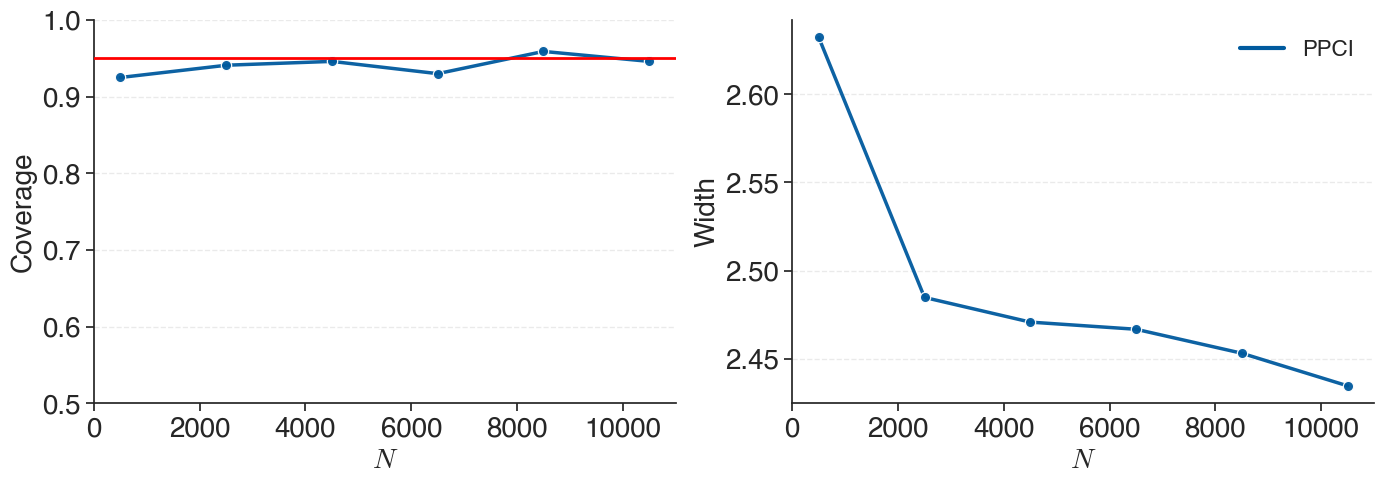

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.font_manager as fm
import os
import numpy as np
from matplotlib.lines import Line2D

# ==========================================
# 0. Font & plotting style configuration
#    - Regular text: Helvetica
#    - Math text: Computer Modern (CMR) style
# ==========================================
FONT_SIZE = 20
font_path = '/home/ysui8/yangsuienv/Helvetica.ttf'
custom_font_name = "Helvetica"

if os.path.exists(font_path):
    try:
        fm.fontManager.addfont(font_path)
        prop = fm.FontProperties(fname=font_path)
        if prop.get_name() != 'Helvetica':
            raise ValueError("Loaded font name mismatch")
        print(f"✅ Font 'Helvetica' loaded successfully.")
    except Exception:
        raise FileNotFoundError(
            f"❌ Unable to load Helvetica font file '{font_path}'. Please ensure the path is correct and the file is valid."
        )
else:
    raise FileNotFoundError(f"❌ Helvetica font file '{font_path}' not found. Please check the path.")

# Regular text uses Helvetica
mpl.rcParams["font.family"] = "sans-serif"
mpl.rcParams["font.sans-serif"] = [custom_font_name]
mpl.rcParams["axes.unicode_minus"] = False
mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42

# ✅ Math text uses CMR (no external LaTeX dependency)
mpl.rcParams["mathtext.fontset"] = "cm"

sns.set_theme(
    style="ticks",
    rc={
        "axes.grid": False,
        "font.sans-serif": [custom_font_name],
    },
)

# ==========================================
# 1. Read sweep CSV (NEW version)
# ==========================================
filename = "./results/census_income_ppci_mean_twofold_cf_sweepN_sex1_age70.csv"
df = pd.read_csv(filename)

# optional: keep only successful rows
if "status" in df.columns:
    df = df[df["status"] == "ok"].copy()

# Required columns for NEW sweep CSV
required_cols = [
    "age", "sex",
    "N_unlab_total", "N_use", "N_t_full",
    "PPCI_coverage", "PPCI_avg_ci_width",
]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"❌ CSV is missing these columns: {missing}")

df["age"] = df["age"].astype(int)
df["sex"] = df["sex"].astype(int)
df["N_unlab_total"] = df["N_unlab_total"].astype(int)
df["N_use"] = df["N_use"].astype(int)
df["N_t_full"] = df["N_t_full"].astype(int)

# Only plot: sex=1, age=70
df = df[(df["sex"] == 1) & (df["age"] == 70)].copy()

# X-axis: |I_2| = N_use  (your sweep uses N_use == N_unlab_total)
df["I2_size"] = df["N_use"]
df = df.sort_values("I2_size")

# ==========================================
# 2. Long format: ONLY Coverage + Width
# ==========================================
plot_data = []
for _, row in df.iterrows():
    nI2 = int(row["I2_size"])
    plot_data += [
        {"I2_size": nI2, "Metric": "Coverage", "Value": float(row["PPCI_coverage"])},
        {"I2_size": nI2, "Metric": "Width",    "Value": float(row["PPCI_avg_ci_width"])},
    ]
df_long = pd.DataFrame(plot_data)

# ==========================================
# 3. Smoothing helper
# ==========================================
def smooth_line(x, y, num=200):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if len(x) <= 1:
        return x, y
    order = np.argsort(x)
    x_sorted = x[order]
    y_sorted = y[order]
    x_new = np.linspace(x_sorted.min(), x_sorted.max(), num=num)
    y_new = np.interp(x_new, x_sorted, y_sorted)
    return x_new, y_new

# ==========================================
# 4. 1×2: Coverage / Width vs |I_2|
# ==========================================
metrics = ["Coverage", "Width"]
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=False, sharey=False)

color_ppci = "#005a9e"

for c, metric in enumerate(metrics):
    ax = axes[c]
    sub = df_long[df_long["Metric"] == metric].copy().sort_values("I2_size")

    x = sub["I2_size"].values
    y = sub["Value"].values
    x_s, y_s = smooth_line(x, y, num=200)

    ax.plot(
        x_s, y_s,
        color=color_ppci,
        linewidth=2.5,
        alpha=0.95,
        zorder=2,
    )
    ax.scatter(
        x, y,
        color=color_ppci,
        marker="o",
        s=55,
        alpha=0.95,
        edgecolors="white",
        linewidths=0.9,
        zorder=3,
    )

    if metric == "Coverage":
        ax.axhline(
            0.95,
            color="red",
            linestyle="-",
            linewidth=2,
            zorder=10,
        )
        ax.set_ylim(0.5, 1.0)

    ax.set_ylabel(metric, fontsize=FONT_SIZE)
    ax.set_xlabel(r"$N$", fontsize=FONT_SIZE)  # ✅ math label in CMR
    ax.tick_params(axis='both', labelsize=FONT_SIZE)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontname(custom_font_name)

# ==========================================
# 5. Axis styling: only x/y spines + horizontal dashed gridlines
# ==========================================
for ax in axes.flat:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(True)
    ax.spines["bottom"].set_visible(True)

    ax.set_axisbelow(True)
    ax.grid(False)
    ax.yaxis.grid(True, linestyle="--", alpha=0.4)
    ax.xaxis.grid(False)

# ==========================================
# 6. Optional legend (single method)
# ==========================================
method_handles = [Line2D([0], [0], color=color_ppci, linewidth=3, label="PPCI")]
axes[1].legend(handles=method_handles, loc="upper right", fontsize=FONT_SIZE-4, frameon=False)

plt.tight_layout()
output_file = "income_mean_sex1_age70_ppci_sweepN_coverage_width.pdf"
plt.savefig(output_file, bbox_inches='tight', dpi=400)
print(f"✅ Figure saved as: {output_file}")
plt.show()

In [1]:
# ============================================================
#  run_census_income_ppci_mean_twofold_cf_sweepN.py
# ============================================================

import os
import sys
import csv
import json  # <--- NEW: 引入 json 库
import numpy as np
import cupy as cp

from ppi_py.datasets import load_dataset
from ppi_py import ppi_mean_ci, ppi_mean_pointestimate

# 兼容：脚本里用 __file__，notebook 里用 os.getcwd()
try:
    current_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    current_dir = os.getcwd()

parent_dir = os.path.abspath(os.path.join(current_dir, ".."))
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

from conditional_mean_functions import (
    preprocess_X,
    make_age_groups,
    select_logell_by_pilot_logo_cv,
    nw_point_mean_ci_matern52,
    build_twofold_weights,
    ppci_conditional_mean_cf,
    ppci_conditional_mean_label_only_cf,
)

np.set_printoptions(precision=4, suppress=True)

def std_ddof1_from_sums(sum_x: float, sum_x2: float, n: int) -> float:
    if n <= 1:
        return 0.0
    var = (sum_x2 - (sum_x * sum_x) / n) / (n - 1)
    return float(np.sqrt(max(var, 0.0)))

def write_results_to_csv(results_list, csv_path):
    if len(results_list) == 0:
        raise ValueError("results_list is empty; nothing to write.")
    fieldnames = list(results_list[0].keys())
    with open(csv_path, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        for row in results_list:
            writer.writerow(row)
    print(f"\n[Saved Checkpoint] {csv_path}")

def run_one_x0_income_twofold_cf(
    Y: np.ndarray, Yhat: np.ndarray, X_raw: np.ndarray, X_scaled: np.ndarray,
    X_mean: np.ndarray, X_std: np.ndarray, X_full_gpu, Y_full_gpu,
    X_pilot_gpu, Y_pilot_gpu, pilot_groups: np.ndarray, pilot_idx: np.ndarray,
    seed_split: int, R: int, B: int, n_label: int, N_unlab_total: int,
    lam_grid: np.ndarray, LOGELL_grid_size: int, c_min: float, c_max: float,
    z_alpha: float, alpha: float, x0_raw: np.ndarray, theta0_mode: str = "smooth",
):
    N_total = int(len(Y))
    x0_raw = np.asarray(x0_raw, dtype=float).ravel()
    x0_scaled = (x0_raw - X_mean) / X_std
    x0_gpu = cp.asarray(x0_scaled)

    mask_x0 = np.all(X_raw == x0_raw.reshape(1, -1), axis=1)
    n_x0 = int(mask_x0.sum())

    theta0_obs = float(np.mean(Y[mask_x0])) if np.any(mask_x0) else np.nan
    dists_full = np.linalg.norm(X_scaled - x0_scaled.reshape(1, -1), axis=1)
    ell_oracle = float(np.median(dists_full))
    theta0_s, _, _ = nw_point_mean_ci_matern52(X_l=X_full_gpu, Y_l=Y_full_gpu, x0=x0_gpu, ell=ell_oracle, z_alpha=z_alpha)
    theta0_smooth = float(theta0_s)

    if theta0_mode == "obs":
        theta0 = theta0_obs
        theta0_source = "obs"
    elif theta0_mode == "smooth":
        theta0 = theta0_smooth
        theta0_source = "smooth"
    else:
        theta0 = theta0_obs if not np.isnan(theta0_obs) else theta0_smooth
        theta0_source = "obs" if not np.isnan(theta0_obs) else "smooth"

    pilot_mask = np.zeros(N_total, dtype=bool)
    pilot_mask[pilot_idx] = True
    base_pool = np.where((~pilot_mask) & (~mask_x0))[0]
    M = int(len(base_pool))

    d_pilot = cp.linalg.norm(X_pilot_gpu - x0_gpu[None, :], axis=1)
    ell0_hat = float(cp.asnumpy(cp.median(d_pilot)))
    ell0_hat = max(1e-8, ell0_hat)

    ell_low = max(1e-8, c_min * ell0_hat)
    ell_high = c_max * ell0_hat
    LOGELL_grid_local = np.linspace(np.log(ell_low), np.log(ell_high), int(LOGELL_grid_size))

    ell_star, _ = select_logell_by_pilot_logo_cv(LOGELL_grid_local, X_pilot_gpu, Y_pilot_gpu, pilot_groups)
    ell_star = float(ell_star)
    total_reps = int(R * B)

    # Variables for aggregation
    sum_th_ppci = sum_sqerr_ppci = sum_cov_ppci = sum_width_ppci = 0.0
    sum_s2_Ymf = sum_s2_Ymf2 = sum_s2_f = sum_s2_f2 = 0.0
    sum_th_lo = sum_sqerr_lo = sum_cov_lo = sum_width_lo = sum_s2_Y = sum_s2_Y2 = 0.0
    sum_th_ppi = sum_sqerr_ppi = sum_cov_ppi = sum_width_ppi = 0.0
    sum_lam1 = sum_lam2 = sum_den_u = 0.0

    raw_widths_ppci = [] # <--- NEW: 用于保存每次循环的宽度

    x0_tag = int(10_000 * int(x0_raw[0]) + 100 * int(x0_raw[1]))

    for r in range(1, R + 1):
        rng_xu = np.random.default_rng(seed_split + 2_000_000 * x0_tag + 20_000 * r)
        idx_u = rng_xu.choice(base_pool, size=N_unlab_total, replace=False)

        perm_u = rng_xu.permutation(N_unlab_total)
        half = N_unlab_total // 2
        idx_fold1, idx_fold2 = perm_u[:half], perm_u[half:]

        X_u_gpu = cp.asarray(X_scaled[idx_u])
        w1_hat, w2_hat, w_oof_u, den_u, lam1, lam2 = build_twofold_weights(
            X_u_gpu, x0_scaled, ell_star, lam_grid, idx_fold1, idx_fold2, make_plot=False
        )

        sum_lam1 += float(lam1)
        sum_lam2 += float(lam2)
        sum_den_u += float(den_u)

        f_u = cp.asarray(Yhat[idx_u]).ravel()
        idx_u_set = set(idx_u.tolist())
        idx_l_pool = np.array([ii for ii in base_pool if ii not in idx_u_set], dtype=int)

        rng_inner = np.random.default_rng(seed_split + 1_000_000 * x0_tag + 10_000 * r)

        for _ in range(B):
            idx_l = rng_inner.choice(idx_l_pool, size=n_label, replace=False)
            X_l = cp.asarray(X_scaled[idx_l])
            Y_l = cp.asarray(Y[idx_l]).ravel()
            f_l = cp.asarray(Yhat[idx_l]).ravel()

            th, se, (lo, up), ex = ppci_conditional_mean_cf(
                X_l, Y_l, f_l, f_u, w1_hat, w2_hat, w_oof_u, z_alpha=z_alpha, return_extras=True
            )

            th = float(th)
            cov = float(lo <= theta0 <= up)
            width = float(up - lo)
            raw_widths_ppci.append(width) # <--- NEW: 保存每次的 width

            sum_th_ppci += th
            sum_sqerr_ppci += (th - theta0) ** 2
            sum_cov_ppci += cov
            sum_width_ppci += width

            s2_y_m_f, s2_fv = float(ex["sigma2_Y_minus_f"]), float(ex["sigma2_f"])
            sum_s2_Ymf += s2_y_m_f
            sum_s2_Ymf2 += s2_y_m_f ** 2
            sum_s2_f += s2_fv
            sum_s2_f2 += s2_fv ** 2

            th2, se2, (lo2, up2), ex2 = ppci_conditional_mean_label_only_cf(
                X_l, Y_l, w1_hat, w2_hat, z_alpha=z_alpha, return_extras=True, denom_floor=1e-10
            )

            th2 = float(th2)
            cov2 = float(lo2 <= theta0 <= up2)
            width2 = float(up2 - lo2)

            sum_th_lo += th2
            sum_sqerr_lo += (th2 - theta0) ** 2
            sum_cov_lo += cov2
            sum_width_lo += width2

            s2y = float(ex2["sigma2_Y"])
            sum_s2_Y += s2y
            sum_s2_Y2 += s2y ** 2

            Y_l_cpu, f_l_cpu, f_u_cpu = cp.asnumpy(Y_l).ravel(), cp.asnumpy(f_l).ravel(), cp.asnumpy(f_u).ravel()
            ppi_lo, ppi_up = ppi_mean_ci(Y_l_cpu, f_l_cpu, f_u_cpu, alpha=alpha)
            ppi_th = float(ppi_mean_pointestimate(Y_l_cpu, f_l_cpu, f_u_cpu))

            cov3 = float(ppi_lo <= theta0 <= ppi_up)
            width3 = float(ppi_up - ppi_lo)

            sum_th_ppi += ppi_th
            sum_sqerr_ppi += (ppi_th - theta0) ** 2
            sum_cov_ppi += cov3
            sum_width_ppi += width3

    out = {
        "age": int(x0_raw[0]), "sex": int(x0_raw[1]), "x0_raw": x0_raw.tolist(),
        "theta0_mode": theta0_mode, "theta0_source": theta0_source,
        "theta0": float(theta0), "theta0_smooth": float(theta0_smooth),
        "ell_oracle": float(ell_oracle), "c_min": float(c_min), "c_max": float(c_max),
        "ell0_hat": float(ell0_hat), "ell_star": float(ell_star),
        "lambda_hat": float(0.5 * (sum_lam1/R + sum_lam2/R)),
        "lambda_1": float(sum_lam1/R), "lambda_2": float(sum_lam2/R),
        "R": int(R), "B": int(total_reps), "n_label": int(n_label),
        "N_unlab_total": int(N_unlab_total), "N_t_full": int(N_unlab_total), "N_use": int(N_unlab_total),
        
        "PPCI_theta_mean": float(sum_th_ppci / total_reps),
        "PPCI_theta_rmse": float(np.sqrt(sum_sqerr_ppci / total_reps)),
        "PPCI_coverage": float(sum_cov_ppci / total_reps),
        "PPCI_avg_ci_width": float(sum_width_ppci / total_reps),
        "PPCI_raw_widths": json.dumps(raw_widths_ppci), # <--- NEW: 存为 JSON 字符串
        
        "LO_theta_rmse": float(np.sqrt(sum_sqerr_lo / total_reps)),
        "LO_coverage": float(sum_cov_lo / total_reps),
        "LO_avg_ci_width": float(sum_width_lo / total_reps),
    }
    return out

if __name__ == "__main__":
    cp.cuda.Device(3).use()
    data = load_dataset("./data/", "census_income")

    scale_y = 10000.0
    Y_total = np.asarray(data["Y"], dtype=float) / scale_y
    Yhat_total = np.asarray(data["Yhat"], dtype=float) / scale_y
    X_total = np.asarray(data["X"], dtype=float)

    seed_split = 2026
    R, B, n_label, n_pilot = 5, 200, 300, 300
    alpha, z_alpha = 0.05, 1.96

    sex_val, age = 1.0, 70
    x0_raw = np.array([float(age), float(sex_val)], dtype=float)

    save_dir = os.path.join(current_dir, "results")
    os.makedirs(save_dir, exist_ok=True)
    csv_path = os.path.join(save_dir, "census_income_ppci_mean_twofold_cf_sweepN_sex1_age70_full.csv")

    all_rows = []
    mask_sex = (X_total[:, 1] == sex_val)
    Y_sex, Yhat_sex, X_sex = Y_total[mask_sex], Yhat_total[mask_sex], X_total[mask_sex]
    X_scaled_sex, X_mean, X_std = preprocess_X(X_sex)

    X_full_gpu, Y_full_gpu = cp.asarray(X_scaled_sex), cp.asarray(Y_sex)
    
    rng_pilot = np.random.default_rng(seed_split + 999)
    pilot_idx = rng_pilot.choice(np.arange(len(Y_sex)), size=n_pilot, replace=False)
    X_pilot_gpu, Y_pilot_gpu = cp.asarray(X_scaled_sex[pilot_idx]), cp.asarray(Y_sex[pilot_idx])
    pilot_groups = make_age_groups(X_sex[pilot_idx, 0], bin_width=1)

    for N_unlab_total in range(500, 10501, 2000):
        lam_grid = np.logspace(np.log10(0.1 / n_label), np.log10(10.0 / n_label), 50)
        out = run_one_x0_income_twofold_cf(
            Y_sex, Yhat_sex, X_sex, X_scaled_sex, X_mean, X_std, X_full_gpu, Y_full_gpu,
            X_pilot_gpu, Y_pilot_gpu, pilot_groups, pilot_idx, seed_split, R, B, n_label,
            N_unlab_total, lam_grid, 50, 0.8, 1.2, z_alpha, alpha, x0_raw, "smooth"
        )
        all_rows.append(out)
        write_results_to_csv(all_rows, csv_path)

/home/ysui8/yangsuienv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



[Saved Checkpoint] /home/ysui8/yangsuienv/PPCI_new/census_income_data/results/census_income_ppci_mean_twofold_cf_sweepN_sex1_age70_full.csv

[Saved Checkpoint] /home/ysui8/yangsuienv/PPCI_new/census_income_data/results/census_income_ppci_mean_twofold_cf_sweepN_sex1_age70_full.csv

[Saved Checkpoint] /home/ysui8/yangsuienv/PPCI_new/census_income_data/results/census_income_ppci_mean_twofold_cf_sweepN_sex1_age70_full.csv

[Saved Checkpoint] /home/ysui8/yangsuienv/PPCI_new/census_income_data/results/census_income_ppci_mean_twofold_cf_sweepN_sex1_age70_full.csv

[Saved Checkpoint] /home/ysui8/yangsuienv/PPCI_new/census_income_data/results/census_income_ppci_mean_twofold_cf_sweepN_sex1_age70_full.csv

[Saved Checkpoint] /home/ysui8/yangsuienv/PPCI_new/census_income_data/results/census_income_ppci_mean_twofold_cf_sweepN_sex1_age70_full.csv
